# 2-3. 일원분산분석(ANOVA)

세 지점 A, B, C의 일별 판매량 평균에 차이가 있는지 확인한다.

## 이 실습의 학습 기준

이 노트북은 한 가지 함수의 결과만 확인하지 않고 다음 흐름으로 학습한다.

1. 데이터 구조에 맞는 검정 방법과 가정을 확인한다.
2. 같은 목적의 방법이 여러 개면 모두 실행해 결과를 비교한다.
3. 일부러 적합하지 않은 방법도 비교할 때는, 왜 최종 결론에 사용하지 않는지 밝힌다.
4. 전제검정 결과가 본 검정 선택에 어떻게 연결되는지 확인한다.
5. p-value뿐 아니라 차이의 방향과 크기까지 해석한다.
6. p-value가 `0.0000`으로 보이는 것은 반올림 결과이며, 실제 확률이 0이라는 뜻은 아니다.
7. 유의수준 α=0.05에서 `p-value < 0.05`면 귀무가설을 기각하고, `p-value >= 0.05`면 귀무가설을 기각하지 못한다.

In [1]:
# 셀 목적: 세 지점의 판매량 비교에 필요한 라이브러리를 불러오고 CSV 데이터를 읽는다.
# 해석 포인트: 한글 그래프 표시와 음수 부호가 깨지지 않도록 Matplotlib 기본 설정을 지정한다.
import numpy as np  # 배열과 평균·분산 등 수치 계산을 위해 NumPy를 np로 불러옴
import pandas as pd  # 표 형태 데이터 처리를 위해 Pandas를 pd로 불러옴
from scipy import stats  # 정규성·t·ANOVA·상관·카이제곱 검정을 위해 scipy.stats를 불러옴
from matplotlib import pyplot as plt  # 통계 그래프를 그리기 위해 pyplot을 plt로 불러옴

plt.rcParams["font.family"] = "Apple SD Gothic Neo"  # 그래프 한글이 깨지지 않도록 macOS 한글 글꼴 지정
plt.rcParams["axes.unicode_minus"] = False  # 그래프의 음수 기호가 정상 표시되도록 설정

sales_df = pd.read_csv(  # 지점별 일별 판매량 CSV를 DataFrame으로 읽음
    "datas2/지점별_일별판매량.csv",  # 결과표 또는 방법 목록에 사용할 이름 지정
    encoding="euc-kr"  # 파일의 한글 문자 인코딩 방식을 지정
)  # 함수 호출에 전달할 인자 목록을 닫음

print(sales_df.head())  # 세 지점 매출 데이터의 앞 5개 행을 출력
print(sales_df.columns)  # 집단 구분과 매출값이 저장된 데이터 열 이름을 출력

   일자  지점A  지점B  지점C
0   1  124  118  216
1   2  147  141  214
2   3  129  130  212
3   4  123  127  179
4   5  147  107  222
Index(['일자', '지점A', '지점B', '지점C'], dtype='str')


## 1. 데이터 분리와 가설 설정

- 귀무가설(H₀): 지점 A, B, C의 평균 판매량은 모두 같다.
- 대립가설(H₁): 세 지점 중 적어도 하나의 평균 판매량은 다르다.

세 쌍을 각각 t-검정하면 다중검정으로 제1종 오류가 커질 수 있으므로, 전체 평균 차이는 먼저 ANOVA로 검정한다.

In [2]:
# 셀 목적: 지점별 열에서 결측값을 제거해 세 개의 독립 표본 배열을 만든다.
# 해석 포인트: 각 집단의 표본크기·평균·표본표준편차를 출력해 차이의 방향과 산포를 먼저 확인한다.
branch_a = sales_df["지점A"].dropna().to_numpy()  # 지점 A의 결측값을 제거하고 NumPy 배열로 변환
branch_b = sales_df["지점B"].dropna().to_numpy()  # 지점 B의 결측값을 제거하고 NumPy 배열로 변환
branch_c = sales_df["지점C"].dropna().to_numpy()  # 지점 C의 결측값을 제거하고 NumPy 배열로 변환

for name, values in [("A", branch_a), ("B", branch_b), ("C", branch_c)]:  # 세 지점 배열을 순회하며 동일한 기술통계 출력
    print(  # 현재 지점의 표본크기·산술평균·표본표준편차를 한 줄로 출력
        f"지점 {name} - 개수: {len(values)}, "  # 현재 지점의 이름과 표본크기를 출력 문자열에 구성
        f"평균: {np.mean(values):.2f}, 표준편차: {np.std(values, ddof=1):.2f}"  # 현재 지점의 평균과 표본표준편차를 소수 둘째 자리로 구성
    )  # 함수 호출에 전달할 인자 목록을 닫음

지점 A - 개수: 30, 평균: 137.87, 표준편차: 11.67
지점 B - 개수: 30, 평균: 136.47, 표준편차: 15.55
지점 C - 개수: 30, 평균: 200.10, 표준편차: 16.98


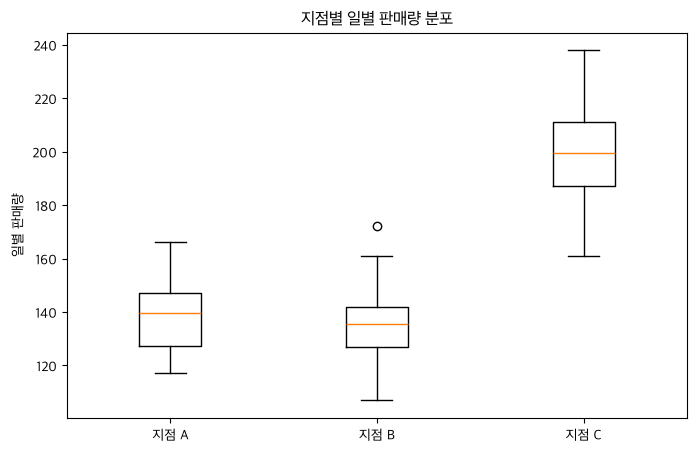

In [3]:
# 셀 목적: 세 지점 판매량의 중앙값·IQR·이상치 후보를 상자그림으로 비교한다.
# 해석 포인트: ANOVA 전에 분포 중심과 퍼짐이 집단별로 크게 다른지 시각적으로 점검한다.
plt.figure(figsize=(8, 5))  # 가로·세로 크기를 지정해 새 그래프 영역 생성
plt.boxplot([branch_a, branch_b, branch_c])  # 세 지점 분포를 중앙값·IQR 중심의 상자그림으로 그림
plt.xticks([1, 2, 3], ["지점 A", "지점 B", "지점 C"])  # x축 눈금 위치와 집단 이름 또는 글자 회전 설정
plt.ylabel("일별 판매량")  # 그래프 y축이 나타내는 측정 단위 이름 설정
plt.title("지점별 일별 판매량 분포")  # 그래프가 표현하는 분석 내용을 제목으로 설정
plt.show()  # 지금까지 설정한 그래프를 화면에 출력

### 1-1. 지점별 KS-test와 Shapiro-Wilk 비교

각 지점에 두 정규성 검정을 모두 적용한다. KS-test는 표본에서 평균과 표준편차를 추정한 학습용 비교이고, 각 지점의 표본 수가 30개이므로 Shapiro-Wilk를 주 판단으로 사용한다.

- 귀무가설(H₀): 해당 지점의 판매량은 정규분포를 따른다.
- 대립가설(H₁): 해당 지점의 판매량은 정규분포를 따르지 않는다.

In [4]:
# 셀 목적: 세 지점 각각에 KS-test와 Shapiro-Wilk를 적용해 정규성 검정 결과를 표로 정리한다.
# 해석 포인트: 검정의 p-value뿐 아니라 앞의 상자그림과 표본크기를 함께 고려한다.
branch_normality_rows = []  # 지점별 정규성 결과를 누적할 빈 목록 생성

for branch_name, branch_values in [  # 세 지점을 차례로 꺼내 같은 정규성 계산 반복
    ("지점 A", branch_a),  # 비교에 사용할 이름·데이터·위치 정보를 하나의 튜플로 정의
    ("지점 B", branch_b),  # 비교에 사용할 이름·데이터·위치 정보를 하나의 튜플로 정의
    ("지점 C", branch_c)  # 마지막 반복 대상으로 지점 C 이름과 배열 지정
]:  # 반복할 지점 목록을 닫고 반복문 본문 시작
    branch_mean = np.mean(branch_values)  # 현재 반복 중인 지점의 평균을 계산
    branch_std = np.std(branch_values, ddof=1)  # 현재 지점의 표본 표준편차를 계산
    ks_result = stats.kstest(  # 현재 변수 또는 집단의 KS-test 결과를 계산
        branch_values,  # 현재 지점 판매량 배열을 KS-test에 전달
        stats.norm.cdf,  # 비교 기준으로 정규분포 누적분포함수 전달
        args=(branch_mean, branch_std)  # 기준 정규분포 CDF에 평균과 표준편차를 전달
    )  # 함수 호출에 전달할 인자 목록을 닫음
    shapiro_result = stats.shapiro(branch_values)  # 현재 변수 또는 집단의 Shapiro-Wilk 결과를 계산

    branch_normality_rows.extend([  # 두 검정 결과 행을 기존 결과 목록에 이어 붙임
        {  # 현재 검정 방법의 결과 한 행을 딕셔너리로 구성하기 시작
            "지점": branch_name,  # 결과가 어느 지점에 해당하는지 기록
            "검정 방법": "KS-test",  # 적용한 통계검정 방법 이름을 기록
            "검정통계량": ks_result.statistic,  # 귀무가설 기준에서 벗어난 정도를 나타내는 통계량 기록
            "p-value": ks_result.pvalue  # 귀무가설 아래에서 현재 이상 결과가 나올 확률 기록
        },  # 현재 검정 결과 행을 닫고 다음 결과 행으로 이어감
        {  # 현재 검정 방법의 결과 한 행을 딕셔너리로 구성하기 시작
            "지점": branch_name,  # 결과가 어느 지점에 해당하는지 기록
            "검정 방법": "Shapiro-Wilk",  # 적용한 통계검정 방법 이름을 기록
            "검정통계량": shapiro_result.statistic,  # 귀무가설 기준에서 벗어난 정도를 나타내는 통계량 기록
            "p-value": shapiro_result.pvalue  # 귀무가설 아래에서 현재 이상 결과가 나올 확률 기록
        }  # 현재 결과 행의 딕셔너리 구성을 마침
    ])  # 목록을 전달한 함수 호출을 마침

branch_normality_comparison = pd.DataFrame(branch_normality_rows)  # 지점별 정규성 검정 결과 목록을 DataFrame으로 변환
branch_normality_comparison["결론"] = branch_normality_comparison["p-value"].apply(  # 유의수준 0.05 기준의 판정 문구를 추가
    lambda p: "정규성 위반 증거 부족" if p >= 0.05 else "정규성 위반 가능성"  # 각 p-value를 받아 0.05 기준의 해석 문구로 변환
)  # 함수 호출에 전달할 인자 목록을 닫음

display(branch_normality_comparison.round(4))  # DataFrame 결과를 표 형태로 노트북에 표시

,지점,검정 방법,검정통계량,p-value,결론
0,지점 A,KS-test,0.1165,0.7671,정규성 위반 증거 부족
1,지점 A,Shapiro-Wilk,0.9654,0.4219,정규성 위반 증거 부족
2,지점 B,KS-test,0.1276,0.6660,정규성 위반 증거 부족
3,지점 B,Shapiro-Wilk,0.9794,0.8099,정규성 위반 증거 부족
4,지점 C,KS-test,0.0758,0.9901,정규성 위반 증거 부족
5,지점 C,Shapiro-Wilk,0.9821,0.8772,정규성 위반 증거 부족


### 1-2. Levene 등분산성 검정

일반 일원분산분석은 세 집단의 분산이 같다고 가정한다. Levene 검정 결과에 따라 일반 ANOVA와 Welch ANOVA 중 주 결과를 선택한다.

- 귀무가설(H₀): 세 지점의 판매량 분산은 같다.
- 대립가설(H₁): 세 지점 중 적어도 하나의 판매량 분산은 다르다.

In [5]:
# 셀 목적: 중앙값 중심 Levene 검정으로 세 지점의 등분산성을 확인한다.
# 해석 포인트: center='median'은 이상치와 비정규성에 더 강건한 Brown-Forsythe 방식에 해당한다.
levene_result = stats.levene(  # 집단 간 등분산성을 확인하는 Levene 검정 결과를 계산
    branch_a,  # 첫 번째 비교 집단인 지점 A 배열 전달
    branch_b,  # 두 번째 비교 집단인 지점 B 배열 전달
    branch_c,  # 세 번째 비교 집단인 지점 C 배열 전달
    center="median"  # 집단 중심을 중앙값으로 두어 이상치 영향을 줄임
)  # 함수 호출에 전달할 인자 목록을 닫음

print(f"Levene 검정통계량: {levene_result.statistic:.4f}")  # 세 지점의 분산 동질성을 검정한 Levene 통계량을 출력
print(f"p-value: {levene_result.pvalue:.4f}")  # 세 지점의 분산이 같다는 Levene 귀무가설의 p-value를 출력
print("일반 ANOVA를 주 결과로 사용:", levene_result.pvalue >= 0.05)  # Levene p-value가 0.05 이상이어서 일반 일원분산분석을 선택했는지 출력

Levene 검정통계량: 1.2446
p-value: 0.2931
일반 ANOVA를 주 결과로 사용: True


## 2. 일반 ANOVA와 Welch ANOVA 비교

- 일반 ANOVA: 집단별 분산이 같다고 가정한다.
- Welch ANOVA: 집단별 분산이 같지 않아도 사용할 수 있다.

두 방식을 모두 실행하되, 최종 결론에는 Levene 결과에 맞는 방식을 사용한다.

In [6]:
# 셀 목적: 일반 ANOVA와 Welch ANOVA를 모두 실행해 등분산 가정에 따른 결과를 비교한다.
# 해석 포인트: Levene p-value에 따라 주 검정을 선택하며 유의한 F는 적어도 한 집단 평균이 다르다는 뜻이다.
classic_anova = stats.f_oneway(  # 등분산을 가정한 일반 일원 ANOVA 결과를 계산
    branch_a,  # 첫 번째 비교 집단인 지점 A 배열 전달
    branch_b,  # 두 번째 비교 집단인 지점 B 배열 전달
    branch_c,  # 세 번째 비교 집단인 지점 C 배열 전달
    equal_var=True  # 두 집단 또는 ANOVA의 등분산 가정 사용 여부 지정
)  # 함수 호출에 전달할 인자 목록을 닫음
welch_anova = stats.f_oneway(  # 등분산을 가정하지 않는 Welch ANOVA 결과를 계산
    branch_a,  # 첫 번째 비교 집단인 지점 A 배열 전달
    branch_b,  # 두 번째 비교 집단인 지점 B 배열 전달
    branch_c,  # 세 번째 비교 집단인 지점 C 배열 전달
    equal_var=False  # 두 집단 또는 ANOVA의 등분산 가정 사용 여부 지정
)  # 함수 호출에 전달할 인자 목록을 닫음

anova_comparison = pd.DataFrame({  # 두 ANOVA 방법의 가정과 결과를 비교표로 구성
    "검정 방법": ["일반 ANOVA", "Welch ANOVA"],  # 적용한 통계검정 방법 이름을 기록
    "등분산 가정": [True, False],  # 각 검정이 두 집단의 동일 분산을 가정하는지 표시
    "F-통계량": [classic_anova.statistic, welch_anova.statistic],  # 집단 간 변동과 집단 내 변동의 비율인 F 통계량 기록
    "p-value": [classic_anova.pvalue, welch_anova.pvalue]  # 귀무가설 아래에서 현재 이상 결과가 나올 확률 기록
})  # 딕셔너리 구성과 함수 호출을 함께 마침
anova_comparison["결론"] = anova_comparison["p-value"].apply(  # 유의수준 0.05 기준의 판정 문구를 추가
    lambda p: "적어도 한 평균이 다름" if p < 0.05 else "평균 차이 증거 부족"  # 각 p-value를 받아 0.05 기준의 해석 문구로 변환
)  # 함수 호출에 전달할 인자 목록을 닫음

display(anova_comparison)  # DataFrame 결과를 표 형태로 노트북에 표시

if levene_result.pvalue >= 0.05:  # Levene p-value로 일반 ANOVA와 Welch ANOVA 중 주 결과 선택
    selected_anova_name = "일반 ANOVA"  # Levene 결과로 선택한 ANOVA 방법 이름을 저장
    anova_result = classic_anova  # 최종 해석에 사용할 ANOVA 결과를 저장
else:  # 앞의 조건이 거짓일 때 사용할 대안 처리 시작
    selected_anova_name = "Welch ANOVA"  # Levene 결과로 선택한 ANOVA 방법 이름을 저장
    anova_result = welch_anova  # 최종 해석에 사용할 ANOVA 결과를 저장

print("Levene 검정에 따라 선택한 방법:", selected_anova_name)  # Levene 결과에 따라 선택한 일반 ANOVA 또는 Welch ANOVA의 이름을 출력
print(f"선택한 검정의 p-value: {anova_result.pvalue:.6g}")  # 선택된 분산분석의 세 지점 평균 동일성 검정 p-value를 출력

,검정 방법,등분산 가정,F-통계량,p-value,결론
0,일반 ANOVA,True,178.438254,1.633742e-31,적어도 한 평균이 다름
1,Welch ANOVA,False,155.562458,1.121908e-23,적어도 한 평균이 다름


Levene 검정에 따라 선택한 방법: 일반 ANOVA
선택한 검정의 p-value: 1.63374e-31


## 3. 보정 전 쌍별 t-검정과 Tukey 사후검정 비교

ANOVA는 어느 지점이 다른지 알려주지 않는다. 지점 쌍을 단순 t-검정한 p-value와 다중비교를 보정한 Tukey p-value를 함께 확인한다.

- 보정 전 쌍별 t-검정: 여러 번 반복하면 우연한 유의성이 증가할 수 있다.
- Tukey HSD: 모든 쌍을 동시에 비교하면서 전체 제1종 오류를 조절한다.

현재는 Levene 검정에서 등분산 위반 증거가 없으므로 Tukey를 사용한다. 등분산 위반 시에는 Welch ANOVA 뒤에 Games-Howell 같은 사후검정을 고려한다.

In [7]:
# 셀 목적: 집단별 독립 t-검정의 보정 전 p-value와 Tukey HSD의 다중비교 보정 p-value를 비교한다.
# 해석 포인트: 사후검정은 반복 비교로 증가하는 가족단위 1종 오류율을 통제한다.
pair_specs = [  # 사후검정에서 비교할 세 지점 쌍과 행렬 위치를 정의
    ("A - B", branch_a, branch_b, 0, 1),  # 비교에 사용할 이름·데이터·위치 정보를 하나의 튜플로 정의
    ("A - C", branch_a, branch_c, 0, 2),  # 비교에 사용할 이름·데이터·위치 정보를 하나의 튜플로 정의
    ("B - C", branch_b, branch_c, 1, 2)  # 지점 B-C 데이터와 Tukey 행렬 위치를 마지막 비교 쌍으로 정의
]  # 목록 정의를 마침

tukey_result = stats.tukey_hsd(branch_a, branch_b, branch_c)  # 세 지점 전체에 대한 Tukey HSD 사후검정 결과를 계산
pairwise_rows = []  # 집단 쌍별 비교 결과를 누적할 빈 목록 생성

for label, first, second, first_index, second_index in pair_specs:  # 세 지점 쌍의 데이터와 Tukey 행렬 위치를 차례로 꺼냄
    raw_t_result = stats.ttest_ind(first, second, equal_var=True)  # 현재 지점 쌍의 보정 전 독립표본 t-검정을 계산
    pairwise_rows.append({  # 현재 반복에서 계산한 결과 한 행을 목록에 추가
        "비교": label,  # 어떤 변수 또는 집단 쌍을 비교했는지 기록
        "평균 차이": np.mean(first) - np.mean(second),  # 첫 번째 집단 평균에서 두 번째 집단 평균을 뺀 값 기록
        "보정 전 t-test p-value": raw_t_result.pvalue,  # 다중비교 보정 전 개별 t-검정 확률 기록
        "Tukey 보정 p-value": tukey_result.pvalue[first_index, second_index]  # Tukey 방법으로 가족단위 오류율을 보정한 확률 기록
    })  # 딕셔너리 구성과 함수 호출을 함께 마침

pairwise_comparison = pd.DataFrame(pairwise_rows)  # 집단 쌍별 t-검정과 Tukey 결과를 DataFrame으로 변환
pairwise_comparison["보정 전 유의"] = (  # 보정 전 p-value가 0.05보다 작은지 표시
    pairwise_comparison["보정 전 t-test p-value"] < 0.05  # 보정 전 p-value가 유의수준 0.05보다 작은지 계산
)  # 함수 호출에 전달할 인자 목록을 닫음
pairwise_comparison["Tukey 유의"] = (  # Tukey 보정 p-value가 0.05보다 작은지 표시
    pairwise_comparison["Tukey 보정 p-value"] < 0.05  # Tukey 보정 p-value가 유의수준 0.05보다 작은지 계산
)  # 함수 호출에 전달할 인자 목록을 닫음

display(pairwise_comparison.round(4))  # DataFrame 결과를 표 형태로 노트북에 표시

,비교,평균 차이,보정 전 t-test p-value,Tukey 보정 p-value,보정 전 유의,Tukey 유의
0,A - B,1.4000,0.6947,0.9297,False,False
1,A - C,-62.2333,0.0000,0.0000,True,True
2,B - C,-63.6333,0.0000,0.0000,True,True


## 4. 분석 결과

- 세 지점 모두 KS-test와 Shapiro-Wilk에서 정규성 위반의 충분한 증거가 없었다.
- Levene 검정 p-value는 0.2931이므로 일반 ANOVA를 주 결과로 선택했다.
- 일반 ANOVA와 Welch ANOVA 모두 세 지점 중 적어도 하나의 평균이 다르다는 결론을 보였다.
- 보정 전 t-검정과 Tukey 모두 A-B는 유의하지 않고 A-C와 B-C는 유의하다는 같은 결론을 보였다.
- 지점 C의 평균은 지점 A보다 약 62.23, 지점 B보다 약 63.63 높았다.
- 최종적으로 전체 차이는 주로 지점 C의 높은 판매량에서 비롯된 것으로 해석한다.